In [62]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [63]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [64]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [65]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2505


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""",null,null,null,null,null,null,true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""20/08/2025""","""1222""","""28 37 09 29 06 49""","""48""","""30""","""Promoción Sí o Sí""","""060928293749""","[6, 9, … 49]",6,9,28,29,37,49,"""06""","""09""","""28""","""29""","""37""","""49""","""08""","""12""","""16""","""17""","""22""","""37""",true,16,"""03_19_01_08_12""",-87,"""2""","""2""","""4""","""3""","""19""","""1""","""8""","""12""","""43""","""2""","""5""","""0"""
"""17/08/2025""","""1221""","""34 11 39 07 26 27""","""37""","""25 22""","""Promoción Sí o Sí""","""071126273439""","[7, 11, … 39]",7,11,26,27,34,39,"""07""","""11""","""26""","""27""","""34""","""39""","""06""","""09""","""28""","""29""","""37""","""49""",false,0,"""04_15_01_07_05""",-73,"""2""","""2""","""4""","""4""","""15""","""1""","""7""","""5""","""32""","""1""","""5""","""0"""
"""13/08/2025""","""1220""","""36 07 43 32 20 33""","""17""","""41 42""","""Promoción Sí o Sí""","""072032333643""","[7, 20, … 43]",7,20,32,33,36,43,"""07""","""20""","""32""","""33""","""36""","""43""","""07""","""11""","""26""","""27""","""34""","""39""",true,16,"""13_12_01_03_07""",-34,"""2""","""3""","""3""","""13""","""12""","""1""","""3""","""7""","""36""","""2""","""5""","""1"""
"""10/08/2025""","""1219""","""24 46 29 19 25 47""","""26""","""06 33 02""","""Promoción Sí o Sí""","""192425294647""","[19, 24, … 47]",19,24,25,29,46,47,"""19""","""24""","""25""","""29""","""46""","""47""","""07""","""20""","""32""","""33""","""36""","""43""",true,16,"""05_01_04_17_01""",-42,"""3""","""2""","""4""","""5""","""1""","""4""","""17""","""1""","""28""","""1""","""4""","""0"""
"""06/08/2025""","""1218""","""38 23 06 21 33 36""","""16""","""49 07""","""Promoción Sí o Sí""","""062123333638""","[6, 21, … 38]",6,21,23,33,36,38,"""06""","""21""","""23""","""33""","""36""","""38""","""19""","""24""","""25""","""29""","""46""","""47""",false,0,"""15_02_10_03_02""",57,"""1""","""3""","""3""","""15""","""2""","""10""","""3""","""2""","""32""","""2""","""4""","""0"""
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""","""06""","""21""","""23""","""33""","""36""","""38""",false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5""","""0"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""


In [66]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""10/08/2025""","""1219""","""24 46 29 19 25 47""","""26""","""06 33 02""","""Promoción Sí o Sí""","""192425294647""","[19, 24, … 47]",19,24,25,29,46,47,"""19""","""24""","""25""","""29""","""46""","""47""","""07""","""20""","""32""","""33""","""36""","""43""",true,16,"""05_01_04_17_01""",-42,"""3""","""2""","""4""","""5""","""1""","""4""","""17""","""1""","""28""","""1""","""4""","""0"""
"""29/06/2025""","""1207""","""47 37 32 22 24 23""","""04""","""20 39 09""","""Promoción Sí o Sí""","""222324323747""","[22, 23, … 47]",22,23,24,32,37,47,"""22""","""23""","""24""","""32""","""37""","""47""","""07""","""10""","""14""","""28""","""29""","""32""",true,24,"""01_01_08_05_10""",35,"""3""","""3""","""3""","""1""","""1""","""8""","""5""","""10""","""25""","""1""","""4""","""0"""
"""15/06/2025""","""1203""","""41 24 42 34 29 44""","""26""","""08 30 39""","""Promoción Sí o Sí""","""242934414244""","[24, 29, … 44]",24,29,34,41,42,44,"""24""","""29""","""34""","""41""","""42""","""44""","""09""","""24""","""26""","""28""","""45""","""50""",true,8,"""05_05_07_01_02""",25,"""2""","""4""","""2""","""5""","""5""","""7""","""1""","""2""","""20""","""0""","""4""","""0"""
"""11/06/2025""","""1202""","""22 39 20 19 38 15""","""32""","""13 35 25""","""Promoción Sí o Sí""","""151920223839""","[15, 19, … 39]",15,19,20,22,38,39,"""15""","""19""","""20""","""22""","""38""","""39""","""24""","""29""","""34""","""41""","""42""","""44""",false,0,"""04_01_02_16_01""",-51,"""1""","""3""","""3""","""4""","""1""","""2""","""16""","""1""","""24""","""1""","""4""","""0"""
"""16/04/2025""","""1186""","""14 31 46 38 48 12""","""15""","""39 30""","""Promoción Sí o Sí""","""121431384648""","[12, 14, … 48]",12,14,31,38,46,48,"""12""","""14""","""31""","""38""","""46""","""48""","""02""","""06""","""11""","""33""","""34""","""42""",false,0,"""02_17_07_08_02""",-54,"""1""","""5""","""1""","""2""","""17""","""7""","""8""","""2""","""36""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [67]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 100)
jdiff_count = count_column(dfRows, 'jdiff', 100)

j1_count = count_column(dfRows, 'j1', 100)
j2_count = count_column(dfRows, 'j2', 100)
j3_count = count_column(dfRows, 'j3', 100)
j4_count = count_column(dfRows, 'j4', 100)
j5_count = count_column(dfRows, 'j5', 100)

joor_count = count_column(dfRows, "joor", 100)
primes_count = count_column(dfRows, 'primes_count', 100)
evens_count = count_column(dfRows, 'evens_count', 100)
odds_count = count_column(dfRows, 'odds_count', 100)

jsums = count_column(dfRows, 'jsum', 100)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [68]:
dfRows.item(0, 'b2')

12

In [69]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [70]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='08'
df_viz FOR str_b1 = 08


post_str_b1,count,percent
str,u32,f64
"""02""",20,15.384615
"""01""",17,13.076923
"""04""",15,11.538462
"""03""",13,10.0
"""05""",11,8.461538
…,…,…
"""18""",2,1.538462
"""16""",1,0.769231
"""22""",1,0.769231


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 08
Last 3 results last_results=['04', '01', '22']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2""","""5""","""0"""
"""08/12/2024""","""1149""","""44 08 45 43 26 17""","""29""","""37 15 36""","""Promoción Sí o Sí""","""081726434445""","[8, 17, … 45]",8,17,26,43,44,45,"""08""","""17""","""26""","""43""","""44""","""45""","""04""","""10""","""31""","""39""","""43""","""46""",true,8,"""09_09_17_01_01""",72,"""2""","""3""","""3""","""9""","""9""","""17""","""1""","""1""","""37""","""1""","""3""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""16/10/2024""","""1134""","""29 31 08 47 12 10""","""50""","""41 33""","""Promoción Sí o Sí""","""081012293147""","[8, 10, … 47]",8,10,12,29,31,47,"""08""","""10""","""12""","""29""","""31""","""47""","""08""","""10""","""15""","""24""","""33""","""50""",true,8,"""02_02_17_02_16""",104,"""3""","""3""","""3""","""2""","""2""","""17""","""2""","""16""","""39""","""2""","""3""","""0"""
"""20/03/2024""","""1074""","""22 08 31 11 10 21""","""06""","""16 43""","""Promoción Sí o Sí""","""081011212231""","[8, 10, … 31]",8,10,11,21,22,31,"""08""","""10""","""11""","""21""","""22""","""31""","""09""","""21""","""25""","""28""","""32""","""48""",false,0,"""02_01_10_01_09""",63,"""2""","""3""","""3""","""2""","""1""","""10""","""1""","""9""","""23""","""1""","""4""","""0"""
"""07/02/2024""","""1062""","""08 30 16 12 48 27""","""40""","""10 17 18""","""Promoción Sí o Sí""","""081216273048""","[8, 12, … 48]",8,12,16,27,30,48,"""08""","""12""","""16""","""27""","""30""","""48""","""01""","""12""","""19""","""27""","""31""","""41""",true,8,"""04_04_11_03_18""",60,"""0""","""5""","""1""","""4""","""4""","""11""","""3""","""18""","""40""","""2""","""4""","""0"""
"""24/12/2023""","""1049""","""36 08 42 25 35 29""","""28""","""02 26 16""","""Promoción Sí o Sí""","""082529353642""","[8, 25, … 42]",8,25,29,35,36,42,"""08""","""25""","""29""","""35""","""36""","""42""","""09""","""19""","""25""","""26""","""45""","""47""",true,16,"""17_04_06_01_06""",39,"""1""","""3""","""3""","""17""","""4""","""6""","""1""","""6""","""34""","""1""","""4""","""0"""
"""26/11/2023""","""1041""","""33 08 40 24 45 41""","""10""","""35 32 27""","""Promoción Sí o Sí""","""082433404145""","[8, 24, … 45]",8,24,33,40,41,45,"""08""","""24""","""33""","""40""","""41""","""45""","""03""","""11""","""12""","""17""","""18""","""39""",false,0,"""16_09_07_01_04""",22,"""1""","""3""","""3""","""16""","""9""","""7""","""1""","""4""","""37""","""1""","""5""","""0"""
"""19/11/2023""","""1039""","""08 23 21 31 19 20""","""16""","""28 33""","""Promoción Sí o Sí""","""081920212331""","[8, 19, … 31]",8,19,20,21,23,31,"""08""","""19""","""20""","""21""","""23""","""31""","""09""","""22""","""23""","""29""","""43""","""48""",true,8,"""11_01_01_02_08""",13,"""3""","""2""","""4""","""11""","""1""","""1""","""2""","""8""","""23""","""1""","""4""","""1"""


df_jumps_map FOR str_b1 = 08


jumps_map,count
str,u32
"""04_05_04_11_06""",1
"""07_20_02_01_04""",1
"""02_08_02_09_03""",1
"""02_12_02_06_04""",1
"""07_04_10_09_04""",1
…,…
"""04_08_06_01_17""",1
"""02_12_06_03_05""",1
"""01_11_04_16_01""",1


df_unijump FOR str_b1 = 08


unijump,count
i64,u32
7,5
28,4
-84,3
-18,3
22,3
…,…
38,1
8,1
-66,1


In [71]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='12'
df_viz FOR str_b2 = 12


post_str_b2,count,percent
str,u32,f64
"""08""",12,8.695652
"""16""",10,7.246377
"""06""",10,7.246377
"""13""",10,7.246377
"""12""",8,5.797101
…,…,…
"""31""",1,0.724638
"""36""",1,0.724638
"""35""",1,0.724638


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 12
Last 3 results last_results=['36', '32', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48""","""4""","""4""","""0"""
"""16/03/2025""","""1177""","""15 30 49 12 05 27""","""23""","""24""","""Promoción Sí o Sí""","""051215273049""","[5, 12, … 49]",5,12,15,27,30,49,"""05""","""12""","""15""","""27""","""30""","""49""","""04""","""32""","""34""","""37""","""41""","""42""",false,0,"""07_03_12_03_19""",74,"""1""","""2""","""4""","""7""","""3""","""12""","""3""","""19""","""44""","""2""","""4""","""0"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""
"""01/12/2024""","""1147""","""42 09 27 12 35 15""","""13""","""48 43 03 08""","""Promoción Sí o Sí""","""091215273542""","[9, 12, … 42]",9,12,15,27,35,42,"""09""","""12""","""15""","""27""","""35""","""42""","""02""","""17""","""20""","""29""","""36""","""38""",true,8,"""03_03_12_08_07""",38,"""0""","""2""","""4""","""3""","""3""","""12""","""8""","""7""","""33""","""1""","""4""","""0"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1""","""5""","""0"""
"""11/02/2024""","""1063""","""19 41 01 31 27 12""","""44""","""35 05""","""Promoción Sí o Sí""","""011219273141""","[1, 12, … 41]",1,12,19,27,31,41,"""01""","""12""","""19""","""27""","""31""","""41""","""03""","""07""","""18""","""29""","""39""","""42""",false,0,"""11_07_08_04_10""",25,"""3""","""1""","""5""","""11""","""7""","""8""","""4""","""10""","""40""","""2""","""5""","""0"""
"""07/02/2024""","""1062""","""08 30 16 12 48 27""","""40""","""10 17 18""","""Promoción Sí o Sí""","""081216273048""","[8, 12, … 48]",8,12,16,27,30,48,"""08""","""12""","""16""","""27""","""30""","""48""","""01""","""12""","""19""","""27""","""31""","""41""",true,8,"""04_04_11_03_18""",60,"""0""","""5""","""1""","""4""","""4""","""11""","""3""","""18""","""40""","""2""","""4""","""0"""
"""03/01/2024""","""1052""","""35 28 12 15 04 39""","""29""","""""","""""","""041215283539""","[4, 12, … 39]",4,12,15,28,35,39,"""04""","""12""","""15""","""28""","""35""","""39""","""01""","""04""","""07""","""18""","""27""","""33""",false,0,"""08_03_13_07_04""",50,"""0""","""3""","""3""","""8""","""3""","""13""","""7""","""4""","""35""","""1""","""5""","""1"""


df_jumps_map FOR str_b2 = 12


jumps_map,count
str,u32
"""02_04_12_11_02""",1
"""06_05_05_04_07""",1
"""07_05_07_11_04""",1
"""02_12_11_02_05""",1
"""05_07_11_10_01""",1
…,…
"""07_01_15_03_11""",1
"""10_01_06_14_07""",1
"""05_05_04_10_08""",1


df_unijump FOR str_b2 = 12


unijump,count
i64,u32
-15,3
5,3
35,3
-30,3
19,3
…,…
-52,1
10,1
-3,1


In [72]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='16'
df_viz FOR str_b3 = 16


post_str_b3,count,percent
str,u32,f64
"""11""",9,7.692308
"""28""",8,6.837607
"""24""",8,6.837607
"""12""",7,5.982906
"""17""",6,5.128205
…,…,…
"""38""",1,0.854701
"""30""",1,0.854701
"""33""",1,0.854701


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 16
Last 3 results last_results=['29', '28', '21']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""
"""26/02/2025""","""1172""","""23 16 12 25 13 21""","""22""","""10 32""","""Promoción Sí o Sí""","""121316212325""","[12, 13, … 25]",12,13,16,21,23,25,"""12""","""13""","""16""","""21""","""23""","""25""","""09""","""18""","""28""","""39""","""44""","""46""",true,8,"""01_03_05_02_02""",13,"""2""","""2""","""4""","""1""","""3""","""5""","""2""","""2""","""13""","""0""","""4""","""1"""
"""16/02/2025""","""1169""","""16 22 34 11 06 45""","""26""","""39 50""","""Promoción Sí o Sí""","""061116223445""","[6, 11, … 45]",6,11,16,22,34,45,"""06""","""11""","""16""","""22""","""34""","""45""","""02""","""19""","""29""","""31""","""44""","""47""",true,8,"""05_05_06_12_11""",-16,"""1""","""4""","""2""","""5""","""5""","""6""","""12""","""11""","""39""","""2""","""4""","""0"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45""","""2""","""4""","""0"""
"""29/05/2024""","""1094""","""04 34 16 10 20 29""","""21""","""28 24 30""","""Promoción Sí o Sí""","""041016202934""","[4, 10, … 34]",4,10,16,20,29,34,"""04""","""10""","""16""","""20""","""29""","""34""","""02""","""08""","""12""","""13""","""26""","""37""",true,8,"""06_06_04_09_05""",-25,"""1""","""5""","""1""","""6""","""6""","""4""","""9""","""5""","""30""","""0""","""4""","""0"""
"""21/04/2024""","""1083""","""29 02 16 36 34 15""","""39""","""13 38""","""Promoción Sí o Sí""","""021516293436""","[2, 15, … 36]",2,15,16,29,34,36,"""02""","""15""","""16""","""29""","""34""","""36""","""04""","""05""","""24""","""26""","""37""","""43""",false,0,"""13_01_13_05_02""",69,"""2""","""4""","""2""","""13""","""1""","""13""","""5""","""2""","""34""","""2""","""4""","""1"""
"""27/03/2024""","""1076""","""30 23 16 06 19 11""","""43""","""18""","""Promoción Sí o Sí""","""061116192330""","[6, 11, … 30]",6,11,16,19,23,30,"""06""","""11""","""16""","""19""","""23""","""30""","""04""","""14""","""17""","""27""","""29""","""43""",true,8,"""05_05_03_04_07""",-6,"""3""","""3""","""3""","""5""","""5""","""3""","""4""","""7""","""24""","""0""","""4""","""0"""
"""07/02/2024""","""1062""","""08 30 16 12 48 27""","""40""","""10 17 18""","""Promoción Sí o Sí""","""081216273048""","[8, 12, … 48]",8,12,16,27,30,48,"""08""","""12""","""16""","""27""","""30""","""48""","""01""","""12""","""19""","""27""","""31""","""41""",true,8,"""04_04_11_03_18""",60,"""0""","""5""","""1""","""4""","""4""","""11""","""3""","""18""","""40""","""2""","""4""","""0"""
"""04/10/2023""","""1026""","""09 05 38 22 16 41""","""06""","""25 44""","""Promoción Sí o Sí""","""050916223841""","[5, 9, … 41]",5,9,16,22,38,41,"""05""","""09""","""16""","""22""","""38""","""41""","""10""","""14""","""17""","""31""","""42""","""46""",false,0,"""04_07_06_16_03""",-49,"""2""","""3""","""3""","""4""","""7""","""6""","""16""","""3""","""36""","""1""","""5""","""0"""


df_jumps_map FOR str_b3 = 16


jumps_map,count
str,u32
"""08_06_03_11_12""",1
"""03_11_02_03_06""",1
"""07_04_17_05_04""",1
"""12_03_10_04_01""",1
"""06_09_14_01_05""",1
…,…
"""13_01_09_09_11""",1
"""08_04_07_04_01""",1
"""06_04_13_08_08""",1


df_unijump FOR str_b3 = 16


unijump,count
i64,u32
4,6
44,4
16,4
2,3
-6,3
…,…
23,1
-89,1
-36,1


In [73]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='17'
df_viz FOR str_b4 = 17


post_str_b4,count,percent
str,u32,f64
"""32""",7,9.333333
"""30""",6,8.0
"""23""",5,6.666667
"""28""",5,6.666667
"""21""",5,6.666667
…,…,…
"""34""",1,1.333333
"""40""",1,1.333333
"""36""",1,1.333333


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 17
Last 3 results last_results=['21', '27', '19']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""27/11/2024""","""1146""","""23 05 17 09 34 13""","""22""","""19 47""","""Promoción Sí o Sí""","""050913172334""","[5, 9, … 34]",5,9,13,17,23,34,"""05""","""09""","""13""","""17""","""23""","""34""","""09""","""12""","""15""","""27""","""35""","""42""",true,9,"""04_04_04_06_11""",-1,"""4""","""1""","""5""","""4""","""4""","""4""","""6""","""11""","""29""","""1""","""3""","""0"""
"""17/12/2023""","""1047""","""05 22 11 17 38 10""","""14""","""07 41 16""","""Promoción Sí o Sí""","""051011172238""","[5, 10, … 38]",5,10,11,17,22,38,"""05""","""10""","""11""","""17""","""22""","""38""","""07""","""09""","""11""","""21""","""27""","""44""",false,0,"""05_01_06_05_16""",33,"""3""","""3""","""3""","""5""","""1""","""6""","""5""","""16""","""33""","""1""","""4""","""0"""
"""29/11/2023""","""1042""","""17 03 11 18 39 12""","""24""","""32 47 19 42""","""Promoción Sí o Sí""","""031112171839""","[3, 11, … 39]",3,11,12,17,18,39,"""03""","""11""","""12""","""17""","""18""","""39""","""01""","""03""","""08""","""19""","""22""","""27""",false,0,"""08_01_05_01_21""",51,"""3""","""2""","""4""","""8""","""1""","""5""","""1""","""21""","""36""","""1""","""4""","""0"""
"""08/03/2023""","""0966""","""17 08 26 10 43 06""","""05""","""18 31 36""","""Promoción Sí o Sí""","""060810172643""","[6, 8, … 43]",6,8,10,17,26,43,"""06""","""08""","""10""","""17""","""26""","""43""","""04""","""29""","""31""","""32""","""40""","""46""",true,8,"""02_02_07_09_17""",17,"""2""","""4""","""2""","""2""","""2""","""7""","""9""","""17""","""37""","""1""","""4""","""0"""
"""01/02/2023""","""0956""","""28 17 24 03 02 13""","""31""","""18 06""","""Promoción Sí o Sí""","""020313172428""","[2, 3, … 28]",2,3,13,17,24,28,"""02""","""03""","""13""","""17""","""24""","""28""","""22""","""23""","""26""","""30""","""37""","""39""",true,1,"""01_10_04_07_04""",-39,"""4""","""3""","""3""","""1""","""10""","""4""","""7""","""4""","""26""","""1""","""4""","""0"""
"""15/01/2023""","""0951""","""17 04 39 13 14 22""","""15""","""""","""""","""041314172239""","[4, 13, … 39]",4,13,14,17,22,39,"""04""","""13""","""14""","""17""","""22""","""39""","""02""","""10""","""11""","""18""","""27""","""46""",false,0,"""09_01_03_05_17""",20,"""2""","""3""","""3""","""9""","""1""","""3""","""5""","""17""","""35""","""1""","""5""","""0"""
"""04/01/2023""","""0948""","""45 04 38 01 14 17""","""07""","""34 42""","""Promoción Sí o Sí""","""010414173845""","[1, 4, … 45]",1,4,14,17,38,45,"""01""","""04""","""14""","""17""","""38""","""45""","""03""","""04""","""10""","""22""","""42""","""44""",true,16,"""03_10_03_21_07""",-96,"""1""","""3""","""3""","""3""","""10""","""3""","""21""","""7""","""44""","""2""","""4""","""0"""
"""30/11/2022""","""0938""","""33 41 09 01 05 17""","""35""","""02 13 36""","""Promoción Sí o Sí""","""010509173341""","[1, 5, … 41]",1,5,9,17,33,41,"""01""","""05""","""09""","""17""","""33""","""41""","""05""","""14""","""24""","""27""","""33""","""40""",true,26,"""04_04_08_16_08""",-20,"""3""","""0""","""6""","""4""","""4""","""8""","""16""","""8""","""40""","""1""","""3""","""0"""
"""25/09/2022""","""0919""","""09 13 44 36 01 17""","""28""","""20 22 05""","""Promoción Sí o Sí""","""010913173644""","[1, 9, … 44]",1,9,13,17,36,44,"""01""","""09""","""13""","""17""","""36""","""44""","""14""","""29""","""30""","""31""","""36""","""38""",true,24,"""08_04_04_19_08""",-52,"""2""","""2""","""4""","""8""","""4""","""4""","""19""","""8""","""43""","""1""","""3""","""0"""


df_jumps_map FOR str_b4 = 17


jumps_map,count
str,u32
"""01_07_05_03_23""",1
"""01_04_05_12_03""",1
"""01_07_04_19_04""",1
"""02_05_02_05_17""",1
"""04_04_04_06_11""",1
…,…
"""07_06_01_01_26""",1
"""06_02_08_13_01""",1
"""02_04_01_14_03""",1


df_unijump FOR str_b4 = 17


unijump,count
i64,u32
4,3
8,3
-9,3
-28,2
28,2
…,…
-51,1
-29,1
-62,1


In [74]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='22'
df_viz FOR str_b5 = 22


post_str_b5,count,percent
str,u32,f64
"""36""",7,11.47541
"""35""",5,8.196721
"""31""",5,8.196721
"""29""",4,6.557377
"""32""",4,6.557377
…,…,…
"""21""",1,1.639344
"""22""",1,1.639344
"""26""",1,1.639344


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 22
Last 3 results last_results=['36', '30']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""
"""30/10/2024""","""1138""","""42 15 22 09 07 18""","""21""","""44 28""","""Promoción Sí o Sí""","""070915182242""","[7, 9, … 42]",7,9,15,18,22,42,"""07""","""09""","""15""","""18""","""22""","""42""","""02""","""04""","""14""","""24""","""36""","""37""",true,16,"""02_06_03_04_20""",0,"""1""","""3""","""3""","""2""","""6""","""3""","""4""","""20""","""35""","""1""","""5""","""0"""
"""07/07/2024""","""1105""","""07 22 34 20 19 09""","""32""","""17 02 35""","""Promoción Sí o Sí""","""070919202234""","[7, 9, … 34]",7,9,19,20,22,34,"""07""","""09""","""19""","""20""","""22""","""34""","""01""","""02""","""21""","""22""","""30""","""40""",false,0,"""02_10_01_02_12""",-28,"""2""","""3""","""3""","""2""","""10""","""1""","""2""","""12""","""27""","""2""","""4""","""0"""
"""20/03/2024""","""1074""","""22 08 31 11 10 21""","""06""","""16 43""","""Promoción Sí o Sí""","""081011212231""","[8, 10, … 31]",8,10,11,21,22,31,"""08""","""10""","""11""","""21""","""22""","""31""","""09""","""21""","""25""","""28""","""32""","""48""",false,0,"""02_01_10_01_09""",63,"""2""","""3""","""3""","""2""","""1""","""10""","""1""","""9""","""23""","""1""","""4""","""0"""
"""17/12/2023""","""1047""","""05 22 11 17 38 10""","""14""","""07 41 16""","""Promoción Sí o Sí""","""051011172238""","[5, 10, … 38]",5,10,11,17,22,38,"""05""","""10""","""11""","""17""","""22""","""38""","""07""","""09""","""11""","""21""","""27""","""44""",false,0,"""05_01_06_05_16""",33,"""3""","""3""","""3""","""5""","""1""","""6""","""5""","""16""","""33""","""1""","""4""","""0"""
"""03/12/2023""","""1043""","""22 08 03 01 27 19""","""34""","""16""","""Promoción Sí o Sí""","""010308192227""","[1, 3, … 27]",1,3,8,19,22,27,"""01""","""03""","""08""","""19""","""22""","""27""","""02""","""12""","""14""","""15""","""18""","""27""",false,0,"""02_05_11_03_05""",41,"""2""","""2""","""4""","""2""","""5""","""11""","""3""","""5""","""26""","""1""","""4""","""0"""
"""02/07/2023""","""0999""","""12 43 20 10 13 22""","""31""","""07 19""","""Promoción Sí o Sí""","""101213202243""","[10, 12, … 43]",10,12,13,20,22,43,"""10""","""12""","""13""","""20""","""22""","""43""","""01""","""05""","""11""","""24""","""28""","""34""",false,0,"""02_01_07_02_21""",53,"""2""","""4""","""2""","""2""","""1""","""7""","""2""","""21""","""33""","""1""","""4""","""0"""
"""10/05/2023""","""0984""","""16 34 09 15 20 22""","""30""","""39 03""","""Promoción Sí o Sí""","""091516202234""","[9, 15, … 34]",9,15,16,20,22,34,"""09""","""15""","""16""","""20""","""22""","""34""","""01""","""02""","""12""","""16""","""24""","""42""",false,0,"""06_01_04_02_12""",30,"""0""","""4""","""2""","""6""","""1""","""4""","""2""","""12""","""25""","""1""","""5""","""0"""
"""07/05/2023""","""0983""","""05 22 04 01 09 23""","""34""","""35 44""","""Promoción Sí o Sí""","""010405092223""","[1, 4, … 23]",1,4,5,9,22,23,"""01""","""04""","""05""","""09""","""22""","""23""","""09""","""15""","""16""","""20""","""22""","""34""",false,0,"""03_01_04_13_01""",-28,"""2""","""2""","""4""","""3""","""1""","""4""","""13""","""1""","""22""","""1""","""4""","""1"""


df_jumps_map FOR str_b5 = 22


jumps_map,count
str,u32
"""08_08_03_02_01""",1
"""02_04_04_05_08""",1
"""01_02_16_01_16""",1
"""05_05_05_05_09""",1
"""06_03_07_04_19""",1
…,…
"""15_01_01_03_15""",1
"""12_02_03_03_21""",1
"""02_05_11_03_05""",1


df_unijump FOR str_b5 = 22


unijump,count
i64,u32
19,3
8,3
16,3
6,2
53,2
…,…
55,1
66,1
32,1


In [75]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='37'
df_viz FOR str_b6 = 37


post_str_blast,count,percent
str,u32,f64
"""45""",16,15.384615
"""42""",14,13.461538
"""43""",14,13.461538
"""44""",11,10.576923
"""41""",7,6.730769
…,…,…
"""22""",1,0.961538
"""34""",1,0.961538
"""39""",1,0.961538


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 37
Last 3 results last_results=['45', '48', '50']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""16/07/2025""","""1212""","""36 22 37 11 07 01""","""24""","""19""","""Promoción Sí o Sí""","""010711223637""","[1, 7, … 37]",1,7,11,22,36,37,"""01""","""07""","""11""","""22""","""36""","""37""","""05""","""06""","""19""","""28""","""42""","""45""",false,0,"""06_04_11_14_01""",1,"""3""","""2""","""4""","""6""","""4""","""11""","""14""","""1""","""36""","""2""","""5""","""1"""
"""04/05/2025""","""1191""","""09 35 19 15 37 10""","""46""","""25 02 38""","""Promoción Sí o Sí""","""091015193537""","[9, 10, … 37]",9,10,15,19,35,37,"""09""","""10""","""15""","""19""","""35""","""37""","""02""","""33""","""35""","""38""","""48""","""50""",true,16,"""01_05_04_16_02""",-57,"""2""","""1""","""5""","""1""","""5""","""4""","""16""","""2""","""28""","""1""","""5""","""0"""
"""03/11/2024""","""1139""","""04 24 37 36 14 02""","""03""","""50 12 42 10""","""Promoción Sí o Sí""","""020414243637""","[2, 4, … 37]",2,4,14,24,36,37,"""02""","""04""","""14""","""24""","""36""","""37""","""02""","""15""","""17""","""40""","""46""","""48""",true,8,"""02_10_10_12_01""",-25,"""2""","""5""","""1""","""2""","""10""","""10""","""12""","""1""","""35""","""3""","""4""","""0"""
"""18/09/2024""","""1126""","""26 10 34 37 21 32""","""45""","""20 15""","""Promoción Sí o Sí""","""102126323437""","[10, 21, … 37]",10,21,26,32,34,37,"""10""","""21""","""26""","""32""","""34""","""37""","""04""","""17""","""20""","""37""","""38""","""48""",false,0,"""11_05_06_02_03""",22,"""1""","""4""","""2""","""11""","""5""","""6""","""2""","""3""","""27""","""1""","""5""","""0"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1""","""5""","""0"""
"""19/06/2024""","""1100""","""37 31 21 15 09 27""","""06""","""32 48""","""Promoción Sí o Sí""","""091521273137""","[9, 15, … 37]",9,15,21,27,31,37,"""09""","""15""","""21""","""27""","""31""","""37""","""05""","""11""","""30""","""35""","""36""","""41""",true,10,"""06_06_06_04_06""",8,"""2""","""0""","""6""","""6""","""6""","""6""","""4""","""6""","""28""","""0""","""2""","""0"""
"""02/06/2024""","""1095""","""26 12 02 08 13 37""","""36""","""03 31 34""","""Promoción Sí o Sí""","""020812132637""","[2, 8, … 37]",2,8,12,13,26,37,"""02""","""08""","""12""","""13""","""26""","""37""","""09""","""14""","""21""","""22""","""24""","""33""",false,0,"""06_04_01_13_11""",-45,"""3""","""4""","""2""","""6""","""4""","""1""","""13""","""11""","""35""","""2""","""5""","""0"""
"""16/11/2022""","""0934""","""14 07 04 21 37 32""","""45""","""18 40 25""","""Promoción Sí o Sí""","""040714213237""","[4, 7, … 37]",4,7,14,21,32,37,"""04""","""07""","""14""","""21""","""32""","""37""","""06""","""10""","""13""","""32""","""37""","""38""",true,8,"""03_07_07_11_05""",-22,"""2""","""3""","""3""","""3""","""7""","""7""","""11""","""5""","""33""","""1""","""4""","""0"""
"""31/08/2022""","""0912""","""15 36 06 24 09 37""","""40""","""16 45 38""","""Promoción Sí o Sí""","""060915243637""","[6, 9, … 37]",6,9,15,24,36,37,"""06""","""09""","""15""","""24""","""36""","""37""","""03""","""23""","""28""","""31""","""37""","""42""",false,0,"""03_06_09_12_01""",-14,"""1""","""3""","""3""","""3""","""6""","""9""","""12""","""1""","""31""","""1""","""5""","""0"""


df_jumps_map FOR str_b6 = 37


jumps_map,count
str,u32
"""03_07_07_11_05""",1
"""01_02_17_06_10""",1
"""04_09_02_10_10""",1
"""02_14_05_08_07""",1
"""01_24_04_05_02""",1
…,…
"""03_06_09_12_01""",1
"""01_01_08_14_10""",1
"""06_06_06_04_06""",1


df_unijump FOR str_b6 = 37


unijump,count
i64,u32
81,3
1,3
-45,3
20,3
-49,3
…,…
-22,1
53,1
-31,1


In [76]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [77]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [78]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 3, 2, 5, 1, 6, 13, 15, 12, 8, 9]
int_jcounts=[2, 3, 4, 1, 5, 8, 11, 6, 9]
int_jcounts=[1, 3, 2, 6, 9, 4, 7, 8, 5, 12, 10, 22]
int_jcounts=[1, 2, 4, 8, 5, 3, 12, 16, 7, 10]
int_jcounts=[2, 1, 3, 5, 11, 10, 9, 15, 7]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jsums[0:15]=['44', '42', '37', '36', '26', '39', '33', '40', '46', '41', '48', '43', '35', '21', '28']


In [ ]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["01", "02", "03", "04", "05", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  pl.col("j1") != "4",
  pl.col("j2") != "4",
  pl.col("j3") != "1",
  pl.col("j4") != "5",
  pl.col("j5") != "15"
  pl.col("jsum") != "29"
)


display(df_possible)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""010204072335""","[1, 2, … 35]",1,2,4,7,23,35,"""01""","""02""","""04""","""07""","""23""","""35""","""01""","""34""",false,0,"""01_02_03_16_12""",-41,"""3""","""2""","""4""","""1""","""2""","""3""","""16""","""12""","""34""","""2""","""5""","""0"""
"""010204072336""","[1, 2, … 36]",1,2,4,7,23,36,"""01""","""02""","""04""","""07""","""23""","""36""","""01""","""35""",false,0,"""01_02_03_16_13""",-40,"""3""","""3""","""3""","""1""","""2""","""3""","""16""","""13""","""35""","""2""","""5""","""0"""
"""010204082135""","[1, 2, … 35]",1,2,4,8,21,35,"""01""","""02""","""04""","""08""","""21""","""35""","""01""","""34""",false,0,"""01_02_04_13_14""",-21,"""1""","""3""","""3""","""1""","""2""","""4""","""13""","""14""","""34""","""2""","""5""","""0"""
"""010204082335""","[1, 2, … 35]",1,2,4,8,23,35,"""01""","""02""","""04""","""08""","""23""","""35""","""01""","""34""",false,0,"""01_02_04_15_12""",-31,"""2""","""3""","""3""","""1""","""2""","""4""","""15""","""12""","""34""","""2""","""5""","""0"""
"""010204082336""","[1, 2, … 36]",1,2,4,8,23,36,"""01""","""02""","""04""","""08""","""23""","""36""","""01""","""35""",false,0,"""01_02_04_15_13""",-30,"""2""","""4""","""2""","""1""","""2""","""4""","""15""","""13""","""35""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435444550""","[9, 24, … 50]",9,24,35,44,45,50,"""09""","""24""","""35""","""44""","""45""","""50""","""09""","""49""",true,16,"""15_11_09_01_05""",26,"""0""","""3""","""3""","""15""","""11""","""9""","""1""","""5""","""41""","""2""","""5""","""0"""
"""092435444647""","[9, 24, … 47]",9,24,35,44,46,47,"""09""","""24""","""35""","""44""","""46""","""47""","""09""","""50""",true,16,"""15_11_09_02_01""",18,"""1""","""3""","""3""","""15""","""11""","""9""","""2""","""1""","""38""","""2""","""5""","""0"""
"""092435444650""","[9, 24, … 50]",9,24,35,44,46,50,"""09""","""24""","""35""","""44""","""46""","""50""","""09""","""49""",true,16,"""15_11_09_02_04""",21,"""0""","""4""","""2""","""15""","""11""","""9""","""2""","""4""","""41""","""2""","""5""","""0"""


### posibles

In [91]:

df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""091020254145""","[9, 10, … 45]",9,10,20,25,41,45,"""09""","""10""","""20""","""25""","""41""","""45""","""09""","""44""",true,16,"""01_10_05_16_04""",-69,"""1""","""2""","""4""","""1""","""10""","""5""","""16""","""4""","""36""","""2""","""5""","""0"""


### anormalias


In [81]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [82]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [83]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [84]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


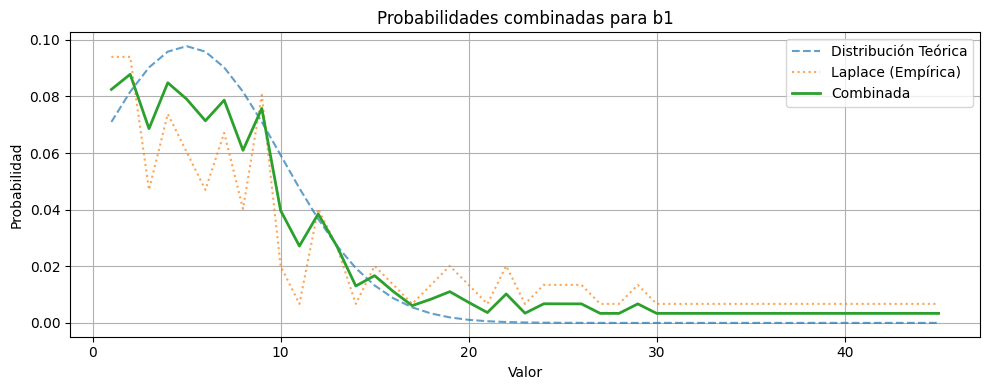

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  4: 0.0848
  1: 0.0825
  5: 0.0791
  7: 0.0787
  9: 0.0758
  6: 0.0714
  3: 0.0686
  8: 0.0610
  10: 0.0397


In [85]:
b1_vals = next_gen_analyze("b1", body_size=104)

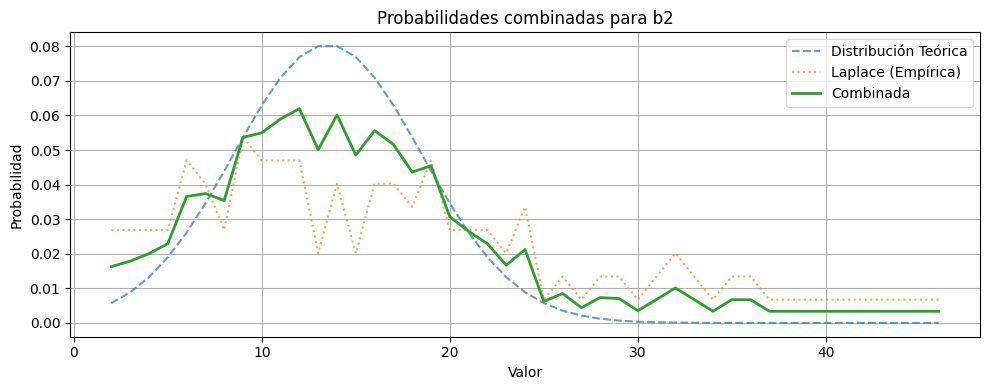

🎯 Siguientes valores más probables para b2:
  12: 0.0619
  14: 0.0602
  11: 0.0590
  16: 0.0556
  10: 0.0550
  9: 0.0537
  17: 0.0516
  13: 0.0501
  15: 0.0485
  19: 0.0455


In [86]:
b2_vals = next_gen_analyze("b2", body_size=104)

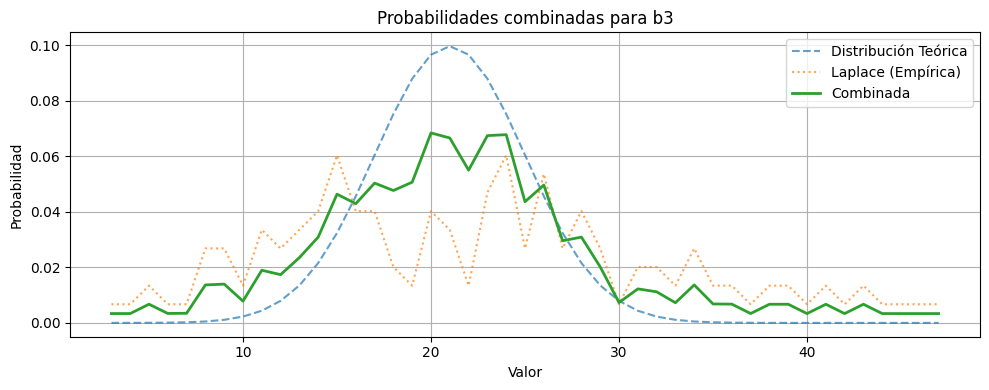

🎯 Siguientes valores más probables para b3:
  20: 0.0685
  24: 0.0678
  23: 0.0675
  21: 0.0666
  22: 0.0550
  19: 0.0507
  17: 0.0504
  26: 0.0497
  18: 0.0477
  15: 0.0464


In [87]:
b3_vals = next_gen_analyze("b3", body_size=104)

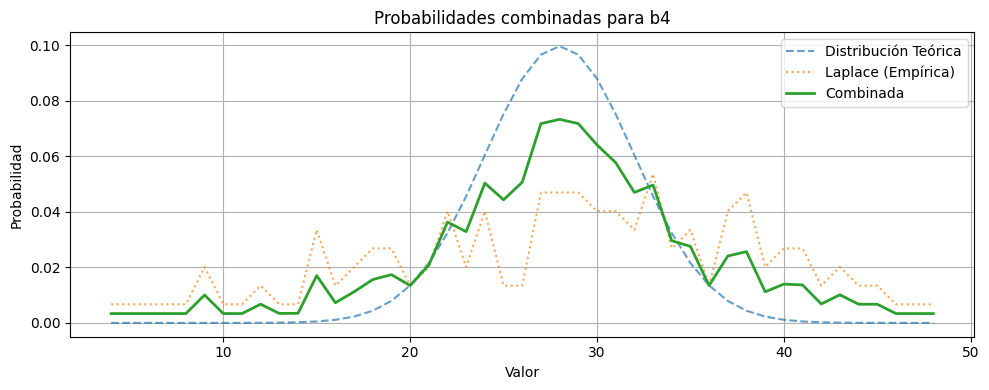

🎯 Siguientes valores más probables para b4:
  28: 0.0734
  27: 0.0718
  29: 0.0718
  30: 0.0641
  31: 0.0578
  26: 0.0507
  24: 0.0504
  33: 0.0497
  32: 0.0470
  25: 0.0444


In [88]:
b4_vals = next_gen_analyze("b4", body_size=104)

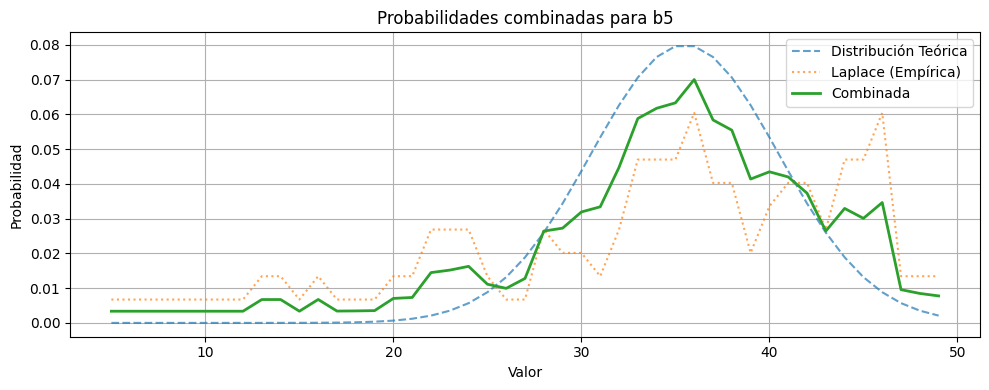

🎯 Siguientes valores más probables para b5:
  36: 0.0700
  35: 0.0633
  34: 0.0617
  33: 0.0588
  37: 0.0584
  38: 0.0554
  32: 0.0447
  40: 0.0435
  41: 0.0420
  39: 0.0414


In [89]:
b5_vals = next_gen_analyze("b5", body_size=104)

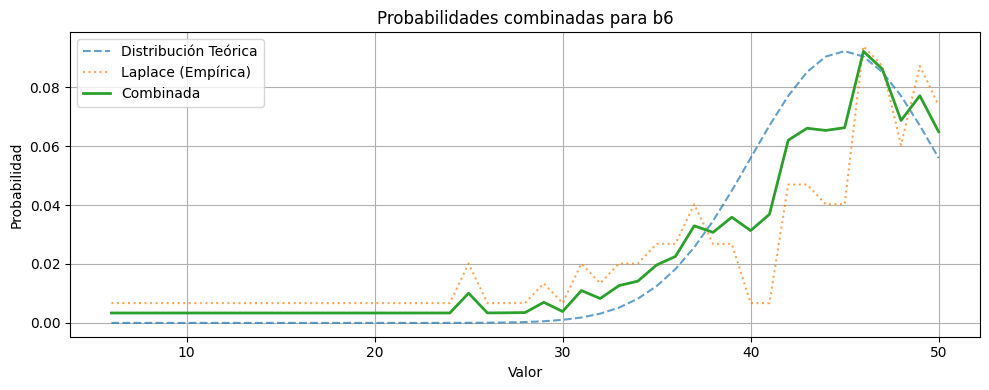

🎯 Siguientes valores más probables para b6:
  46: 0.0922
  47: 0.0862
  49: 0.0771
  48: 0.0687
  45: 0.0663
  43: 0.0661
  44: 0.0654
  50: 0.0649
  42: 0.0620
  41: 0.0369


In [90]:
b6_vals = next_gen_analyze("b6", body_size=104)